Epoch 1, Loss: 2.858946111966979
Epoch 2, Loss: 2.1641362568117537
Epoch 3, Loss: 1.5616938719209634
Epoch 4, Loss: 1.0459513990384228
Epoch 5, Loss: 0.7142786546698157
Epoch 6, Loss: 0.4913736882637132
Epoch 7, Loss: 0.30763441036051176
Epoch 8, Loss: 0.138436195528451
Epoch 9, Loss: 0.2327822985233001
Epoch 10, Loss: 0.14900234376765648
Training Finished


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


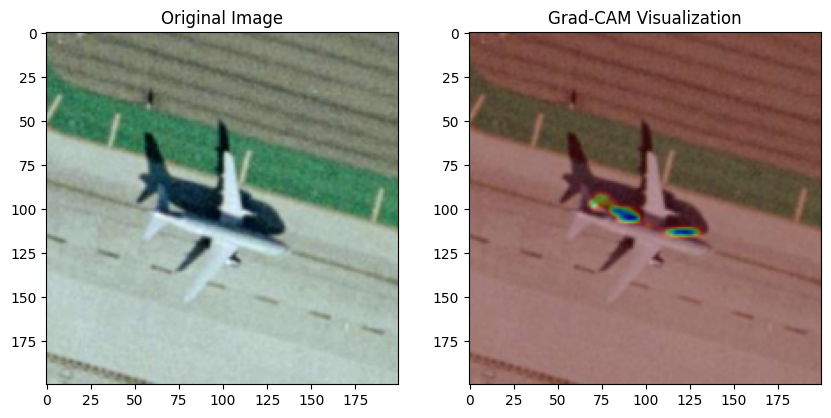

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from PIL import Image

# Set dataset path
dataset_path = "/content/drive/MyDrive/data/Images"
img_size = (200, 200)
batch_size = 32

def load_data(dataset_path, img_size, batch_size):
    transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
    ])
    dataset = torchvision.datasets.ImageFolder(root=dataset_path, transform=transform)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, len(dataset.classes)

train_loader, val_loader, num_classes = load_data(dataset_path, img_size, batch_size)

# Define a small CNN model
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 25 * 25, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN(num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")
    print("Training Finished")

train_model(model, train_loader, val_loader, criterion, optimizer)

# Grad-CAM Visualization
def get_gradcam(model, img_tensor, class_index):
    model.eval()
    feature_maps = []
    gradients = []
    def forward_hook(module, input, output):
        feature_maps.append(output)
    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    model.conv3.register_forward_hook(forward_hook)
    model.conv3.register_backward_hook(backward_hook)

    output = model(img_tensor.unsqueeze(0))
    model.zero_grad()
    class_loss = output[0, class_index]
    class_loss.backward()

    grad = gradients[0].detach()
    fmap = feature_maps[0].detach()
    pooled_grad = torch.mean(grad, dim=[0, 2, 3])
    heatmap = torch.mean(pooled_grad.view(-1, 1, 1) * fmap, dim=1).squeeze()
    heatmap = np.maximum(heatmap.numpy(), 0)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
    return heatmap

# Select an image from the dataset
sample_img_path = os.path.join(dataset_path, "airplane/airplane01.tif")
sample_img = Image.open(sample_img_path).convert('RGB')
sample_img = transforms.Resize(img_size)(sample_img)
sample_img = transforms.ToTensor()(sample_img)

output = model(sample_img.unsqueeze(0))
predicted_class = torch.argmax(output).item()

# Generate Grad-CAM heatmap
heatmap = get_gradcam(model, sample_img, predicted_class)
heatmap = cv2.resize(heatmap, img_size)

# Superimpose heatmap on image
original_img = np.array(transforms.ToPILImage()(sample_img))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
superimposed_img = cv2.addWeighted(original_img, 0.6, heatmap, 0.4, 0)

# Display the image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Original Image")
plt.subplot(1, 2, 2)
plt.imshow(superimposed_img)
plt.title("Grad-CAM Visualization")
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from PIL import Image

# Set dataset path
dataset_path = "/content/drive/MyDrive/data/Images"
img_size = (200, 200)
batch_size = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_data(dataset_path, img_size, batch_size):
    transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
    ])
    dataset = torchvision.datasets.ImageFolder(root=dataset_path, transform=transform)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, len(dataset.classes)

train_loader, val_loader, num_classes = load_data(dataset_path, img_size, batch_size)

# Define a deep CNN model optimized for CUDA T4
class DeepCNN(nn.Module):
    def __init__(self, num_classes):
        super(DeepCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.AdaptiveAvgPool2d((1, 1))  # Ensure fixed output size
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(1024, 1024),  # Instead of 1024 * 28 * 28
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # Flatten dynamically
        x = self.fc_layers(x)
        return x


    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

model = DeepCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_accuracy = 100 * correct_train / total_train

        model.eval()
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_accuracy = 100 * correct_val / total_val

        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}, Train Acc: {train_accuracy:.2f}%, Val Acc: {val_accuracy:.2f}%")

    print("Training Finished")

train_model(model, train_loader, val_loader, criterion, optimizer)

# Grad-CAM Visualization
def get_gradcam(model, img_tensor, class_index):
    model.eval()
    feature_maps = []
    gradients = []
    def forward_hook(module, input, output):
        feature_maps.append(output)
    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    model.conv_layers[-2].register_forward_hook(forward_hook)
    model.conv_layers[-2].register_backward_hook(backward_hook)

    img_tensor = img_tensor.to(device)
    output = model(img_tensor.unsqueeze(0))
    model.zero_grad()
    class_loss = output[0, class_index]
    class_loss.backward()

    grad = gradients[0].detach()
    fmap = feature_maps[0].detach()
    pooled_grad = torch.mean(grad, dim=[0, 2, 3])
    heatmap = torch.mean(pooled_grad.view(-1, 1, 1) * fmap, dim=1).squeeze()
    heatmap = np.maximum(heatmap.cpu().numpy(), 0)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
    return heatmap

# Select an image from the dataset
sample_img_path = os.path.join(dataset_path, "airplane/airplane01.tif")
sample_img = Image.open(sample_img_path).convert('RGB')
sample_img = transforms.Resize(img_size)(sample_img)
sample_img = transforms.ToTensor()(sample_img)

output = model(sample_img.unsqueeze(0).to(device))
predicted_class = torch.argmax(output).item()

heatmap = get_gradcam(model, sample_img, predicted_class)
heatmap = cv2.resize(heatmap, img_size)

original_img = np.array(transforms.ToPILImage()(sample_img))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
superimposed_img = cv2.addWeighted(original_img, 0.6, heatmap, 0.4, 0)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Original Image")
plt.subplot(1, 2, 2)
plt.imshow(superimposed_img)
plt.title("Grad-CAM Visualization")
plt.show()
